In [91]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path
import os


In [92]:
# reading the data 
data = pd.read_csv(r'C:\Users\IKE\Desktop\Human_VS_AI\ai_vs_human_text_2026.csv')
data.head(5)

,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


In [93]:
# checking for any missing values
def basic_checkups(data):
    '''
    Args: Takes in data and checks null values and duplicates
    
    Returns:
      Duplicated value counts and null value counts
    '''
    try:
        null_values = data.isnull().sum()
        duplicates = data.duplicated().sum()
        return print(null_values), print(duplicates)
    except Exception as e:
        print(e)
check = basic_checkups(data) 
print(check)

text_id                0
label                  0
source_model           0
domain                 0
text_content           0
topic_hint             0
word_count             0
avg_sentence_length    0
generation_method      0
dtype: int64
0
(None, None)


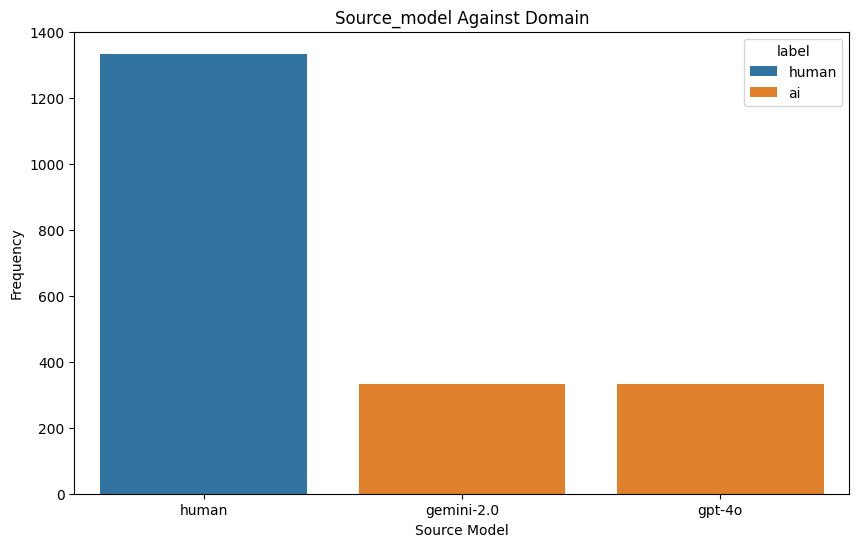

In [94]:
def plot_the_data(x:str,hue:str):
    '''
    Args: Takes in column parameters
    first parameter being the columnname
    second parameter the hue
    
    Returns:
      A histogram of the column parameters
     
    '''
    try:
        plt.figure(figsize=(10,6))
        sns.countplot(x=x,data=data,hue=hue)
        plt.title('Source_model Against Domain')
        plt.xlabel('Source Model')
        plt.ylabel('Frequency')
        plt.show()
    except Exception as e:
        print(e)

plot_the_data('source_model','label')

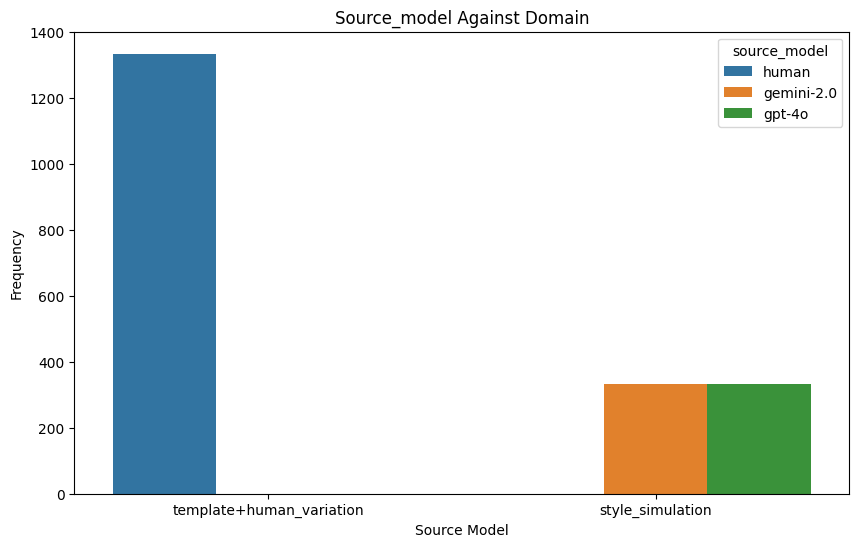

In [95]:
plot_the_data('generation_method','source_model')

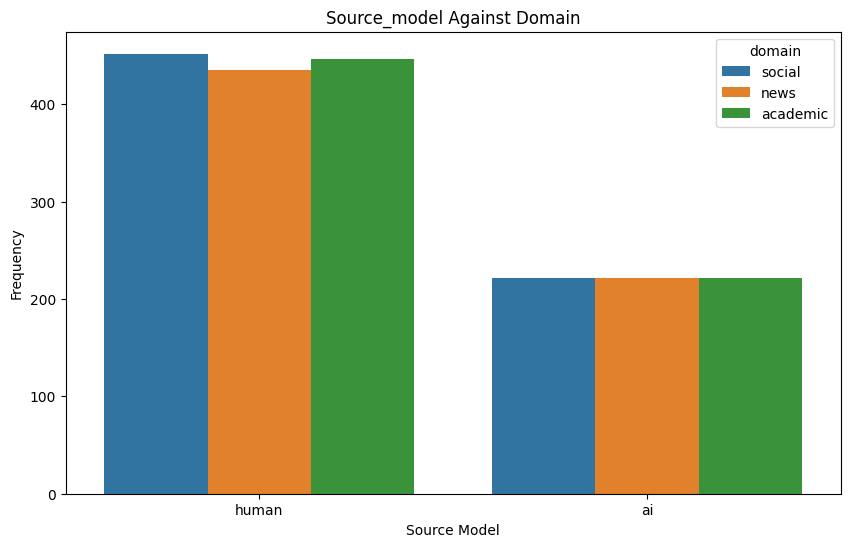

In [96]:
plot_the_data('label','domain')

Text(0.5, 1.0, 'Most Common Words in AI Class')

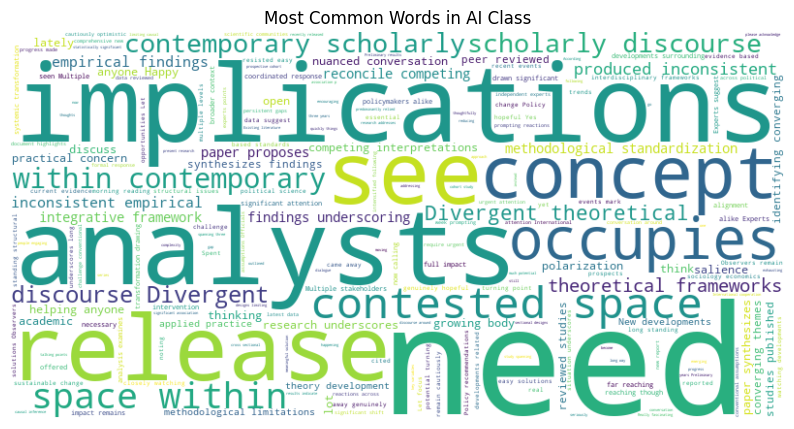

In [97]:
AI_generated_text = data[data['label'] == 'ai']['text_content']
ai_words = ' '.join(AI_generated_text)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ai_words)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in AI Class')

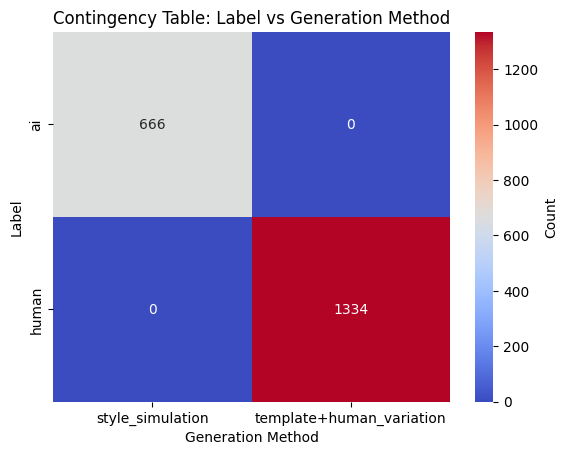

In [98]:
# Create a contingency table heatmap for categorical comparison
crosstab = pd.crosstab(data['label'], data['generation_method'])
sns.heatmap(crosstab, annot=True, cmap='coolwarm', fmt='d', cbar_kws={'label': 'Count'})
plt.title('Contingency Table: Label vs Generation Method')
plt.ylabel('Label')
plt.xlabel('Generation Method')
plt.show()

In [99]:
#dropping some features that are not needed
cols_to_drop = ['text_id','source_model','domain','topic_hint','word_count','avg_sentence_length','generation_method']

for col in cols_to_drop:
    data.drop(columns=col,inplace=True,axis=1)


In [100]:
data.head()

,label,text_content
0,human,can we talk about gene editing ethics for a se...
1,human,update on election integrity concerns: it's co...
2,ai,Analysts are closely watching developments rel...
3,human,This paper examines genomic research breakthro...
4,ai,Existing literature on student debt crisis has...


In [103]:
new_data = data.copy()

#saving the new data
save_data = new_data.to_csv('AI VS Human.csv',index=False)
print(f'The New data was successfully saved')

The New data was successfully saved
